# Pharmaceutical Laboratory Data: EDA

**Dataset:** Žagar & Mihelič (2022), *Scientific Data*, Lek Pharmaceuticals  
**Source:** Figshare DOI 10.6084/m9.figshare.c.5645578  
**Scope:** 1,005 production batches · 55 features · 4 product strengths · Nov 2018 – Mar 2021

This notebook covers:
1. Dataset overview & missing values  
2. Product / batch distribution  
3. Time-series trends  
4. Key quality parameter distributions (API content, dissolution, hardness, impurities)  
5. Correlation heatmap  
6. Principal Component Analysis (PCA)  
7. Anomaly injection preview  
8. Summary & implications for RCA modelling


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Style ─────────────────────────────────────────────────────────────────────
NAVY   = "#1A3557"
BLUE   = "#2563A8"
RED    = "#C8360A"
AMBER  = "#D4873A"
GREEN  = "#1A7A4A"
GREY   = "#718096"
LIGHT  = "#EBF0F7"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    "#CBD5E0",
    "axes.labelcolor":   "#1A1A1A",
    "axes.labelsize":    12,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "xtick.color":       "#4A5568",
    "ytick.color":       "#4A5568",
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "grid.color":        "#E2E8F0",
    "grid.linewidth":    0.7,
    "legend.fontsize":   10,
    "font.family":       "DejaVu Sans",
    "figure.dpi":        110,
})

print("Imports OK")


Imports OK


In [ ]:
# ── Load ─────────────────────────────────────────────────────────────────────
##

# Load data
lab  = pd.read_csv(lab_path, sep=";")
norm = pd.read_csv(norm_path, sep=";")

# Parse month-year production start into sortable period
MONTH_MAP = {
    "jan":1,"feb":2,"mar":3,"apr":4,"maj":5,"jun":6,
    "jul":7,"avg":8,"sep":9,"okt":10,"nov":11,"dec":12
}
def parse_start(s):
    parts = str(s).split(".")
    return pd.Period(year=int("20"+parts[1]), month=MONTH_MAP.get(parts[0].lower(),1), freq="M")

lab["period"]     = lab["start"].apply(parse_start)
lab["period_str"] = lab["period"].astype(str)
lab = lab.sort_values("period").reset_index(drop=True)

# Merge normalisation factor
lab = lab.merge(norm.rename(columns={"Product code":"code","Normalisation factor":"norm_factor"})[["code","norm_factor"]],
                on="code", how="left")

print(f"Shape: {lab.shape[0]} batches × {lab.shape[1]} columns")
lab.head(3)


## 1. Dataset Overview & Missing Values

In [4]:
# ── 1a. Basic info ───────────────────────────────────────────────────────────
print("=" * 55)
print(f"  Batches:      {lab.shape[0]:>6}")
print(f"  Features:     {lab.shape[1]-3:>6}  (excl. derived columns)")
print(f"  Strengths:    {lab['strength'].nunique():>6}  ({', '.join(lab['strength'].unique())})")
print(f"  Product codes:{lab['code'].nunique():>6}")
print(f"  Date range:   {lab['period_str'].min()} → {lab['period_str'].max()}")
print("=" * 55)
lab.select_dtypes(include=np.number).describe().round(3).T[["count","mean","std","min","max"]]


  Batches:        1005
  Features:         55  (excl. derived columns)
  Strengths:         4  (5MG, 10M, 20M, 40M)
  Product codes:    25
  Date range:   2018-11 → 2021-04


,count,mean,std,min,max
batch,1005.0,503.000,290.263,1.000,1005.000
code,1005.0,15.424,7.103,1.000,25.000
size,1005.0,1059289.552,711428.569,240000.000,4800000.000
api_code,1005.0,3.377,1.352,1.000,5.000
api_batch,1005.0,123.257,72.399,1.000,254.000
smcc_batch,1005.0,9.253,5.113,1.000,18.000
lactose_batch,1005.0,11.063,5.811,1.000,22.000
starch_batch,1005.0,9.439,4.492,1.000,17.000
api_content,1003.0,94.418,0.399,93.300,95.600
lactose_water,1005.0,0.054,0.008,0.050,0.080


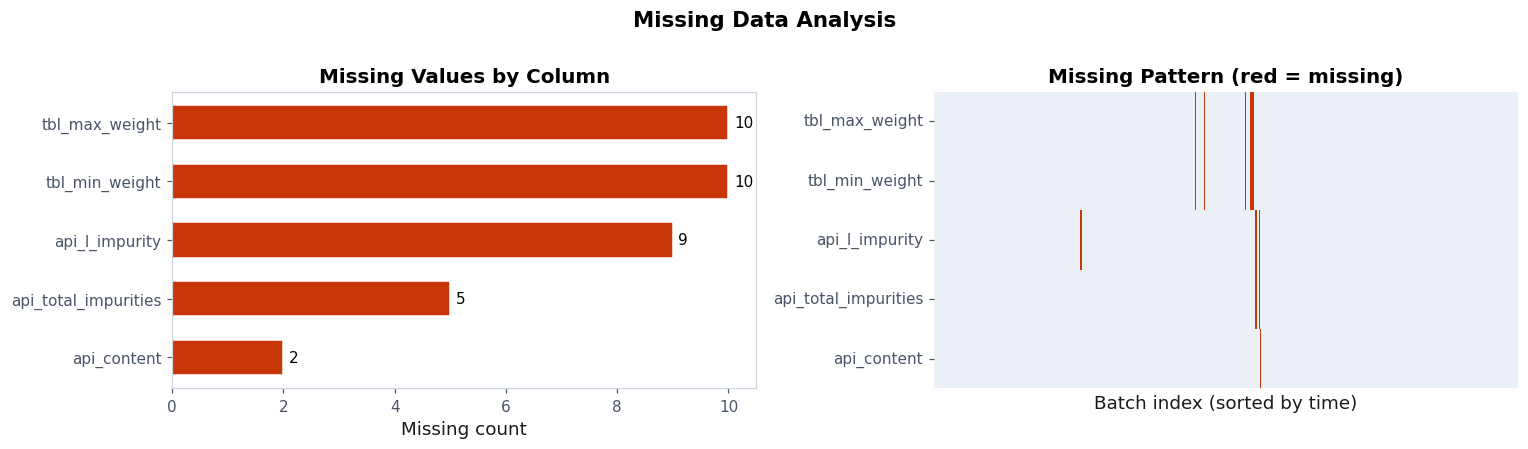


Total missing cells: 36 / 5025


In [5]:
# ── 1b. Missing values heatmap ───────────────────────────────────────────────
miss = lab.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
axes[0].barh(miss.index, miss.values, color=RED, edgecolor="white", height=0.6)
axes[0].set_xlabel("Missing count")
axes[0].set_title("Missing Values by Column")
axes[0].invert_yaxis()
for i, v in enumerate(miss.values):
    axes[0].text(v + 0.1, i, str(v), va="center", fontsize=10)

# Mini heatmap of missing pattern
miss_cols = miss.index.tolist()
miss_mat   = lab[miss_cols].isnull().astype(int)
sns.heatmap(miss_mat.T, cmap=["#EBF0F7", RED], cbar=False,
            xticklabels=False, yticklabels=miss_cols, ax=axes[1],
            linewidths=0, linecolor="white")
axes[1].set_xlabel("Batch index (sorted by time)")
axes[1].set_title("Missing Pattern (red = missing)")

plt.suptitle("Missing Data Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig01_missing.png", bbox_inches="tight", dpi=130)
plt.show()
print(f"\nTotal missing cells: {lab.isnull().sum().sum()} / {lab.shape[0] * len(miss_cols)}")


## 2. Product & Batch Distribution

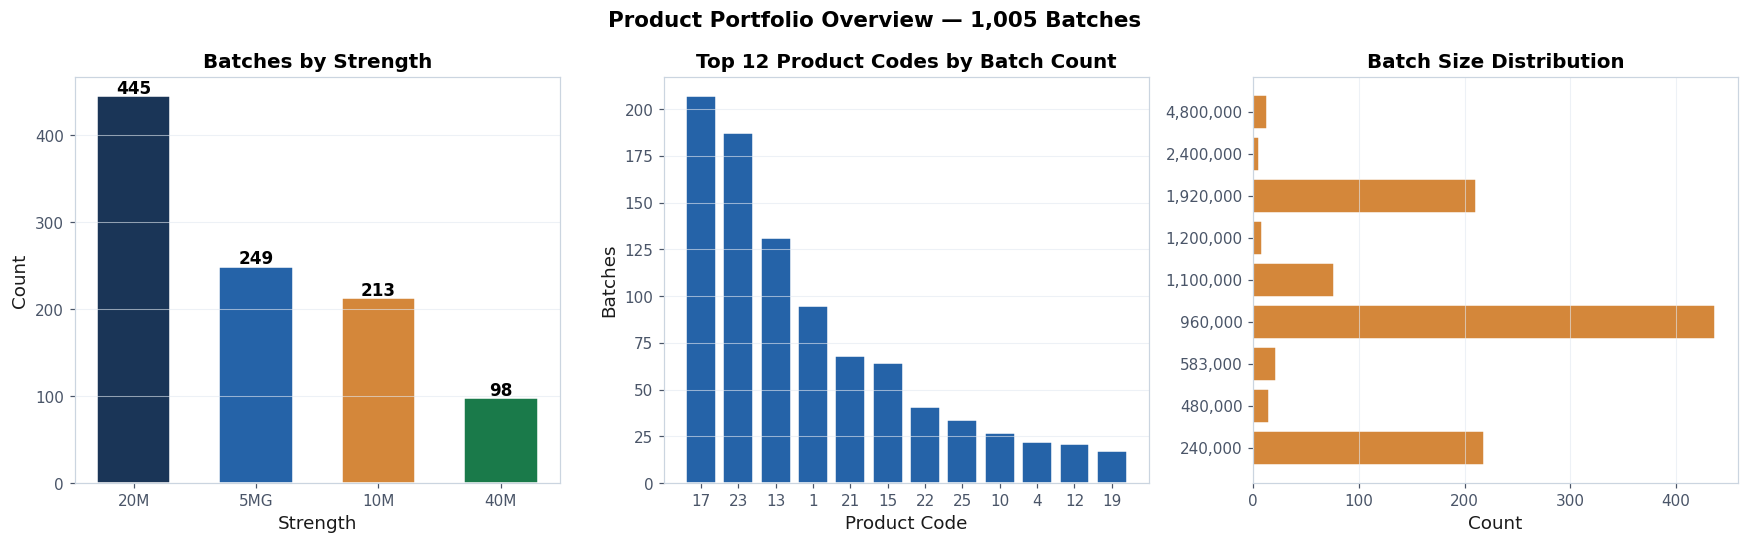

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Strength distribution
strength_counts = lab["strength"].value_counts()
colors = [NAVY, BLUE, AMBER, GREEN]
axes[0].bar(strength_counts.index, strength_counts.values, color=colors, edgecolor="white", width=0.6)
for i, v in enumerate(strength_counts.values):
    axes[0].text(i, v + 3, str(v), ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Batches by Strength")
axes[0].set_xlabel("Strength")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.6)

# Top product codes
top_codes = lab["code"].value_counts().head(12)
axes[1].bar(top_codes.index.astype(str), top_codes.values, color=BLUE, edgecolor="white")
axes[1].set_title("Top 12 Product Codes by Batch Count")
axes[1].set_xlabel("Product Code")
axes[1].set_ylabel("Batches")
axes[1].grid(axis="y", alpha=0.6)

# Batch size distribution
size_counts = lab["size"].value_counts().sort_index()
axes[2].barh([f"{int(s):,}" for s in size_counts.index], size_counts.values, color=AMBER, edgecolor="white")
axes[2].set_title("Batch Size Distribution")
axes[2].set_xlabel("Count")
axes[2].grid(axis="x", alpha=0.6)

plt.suptitle("Product Portfolio Overview — 1,005 Batches", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig02_product_dist.png", bbox_inches="tight", dpi=130)
plt.show()


## 3. Time-Series Trends

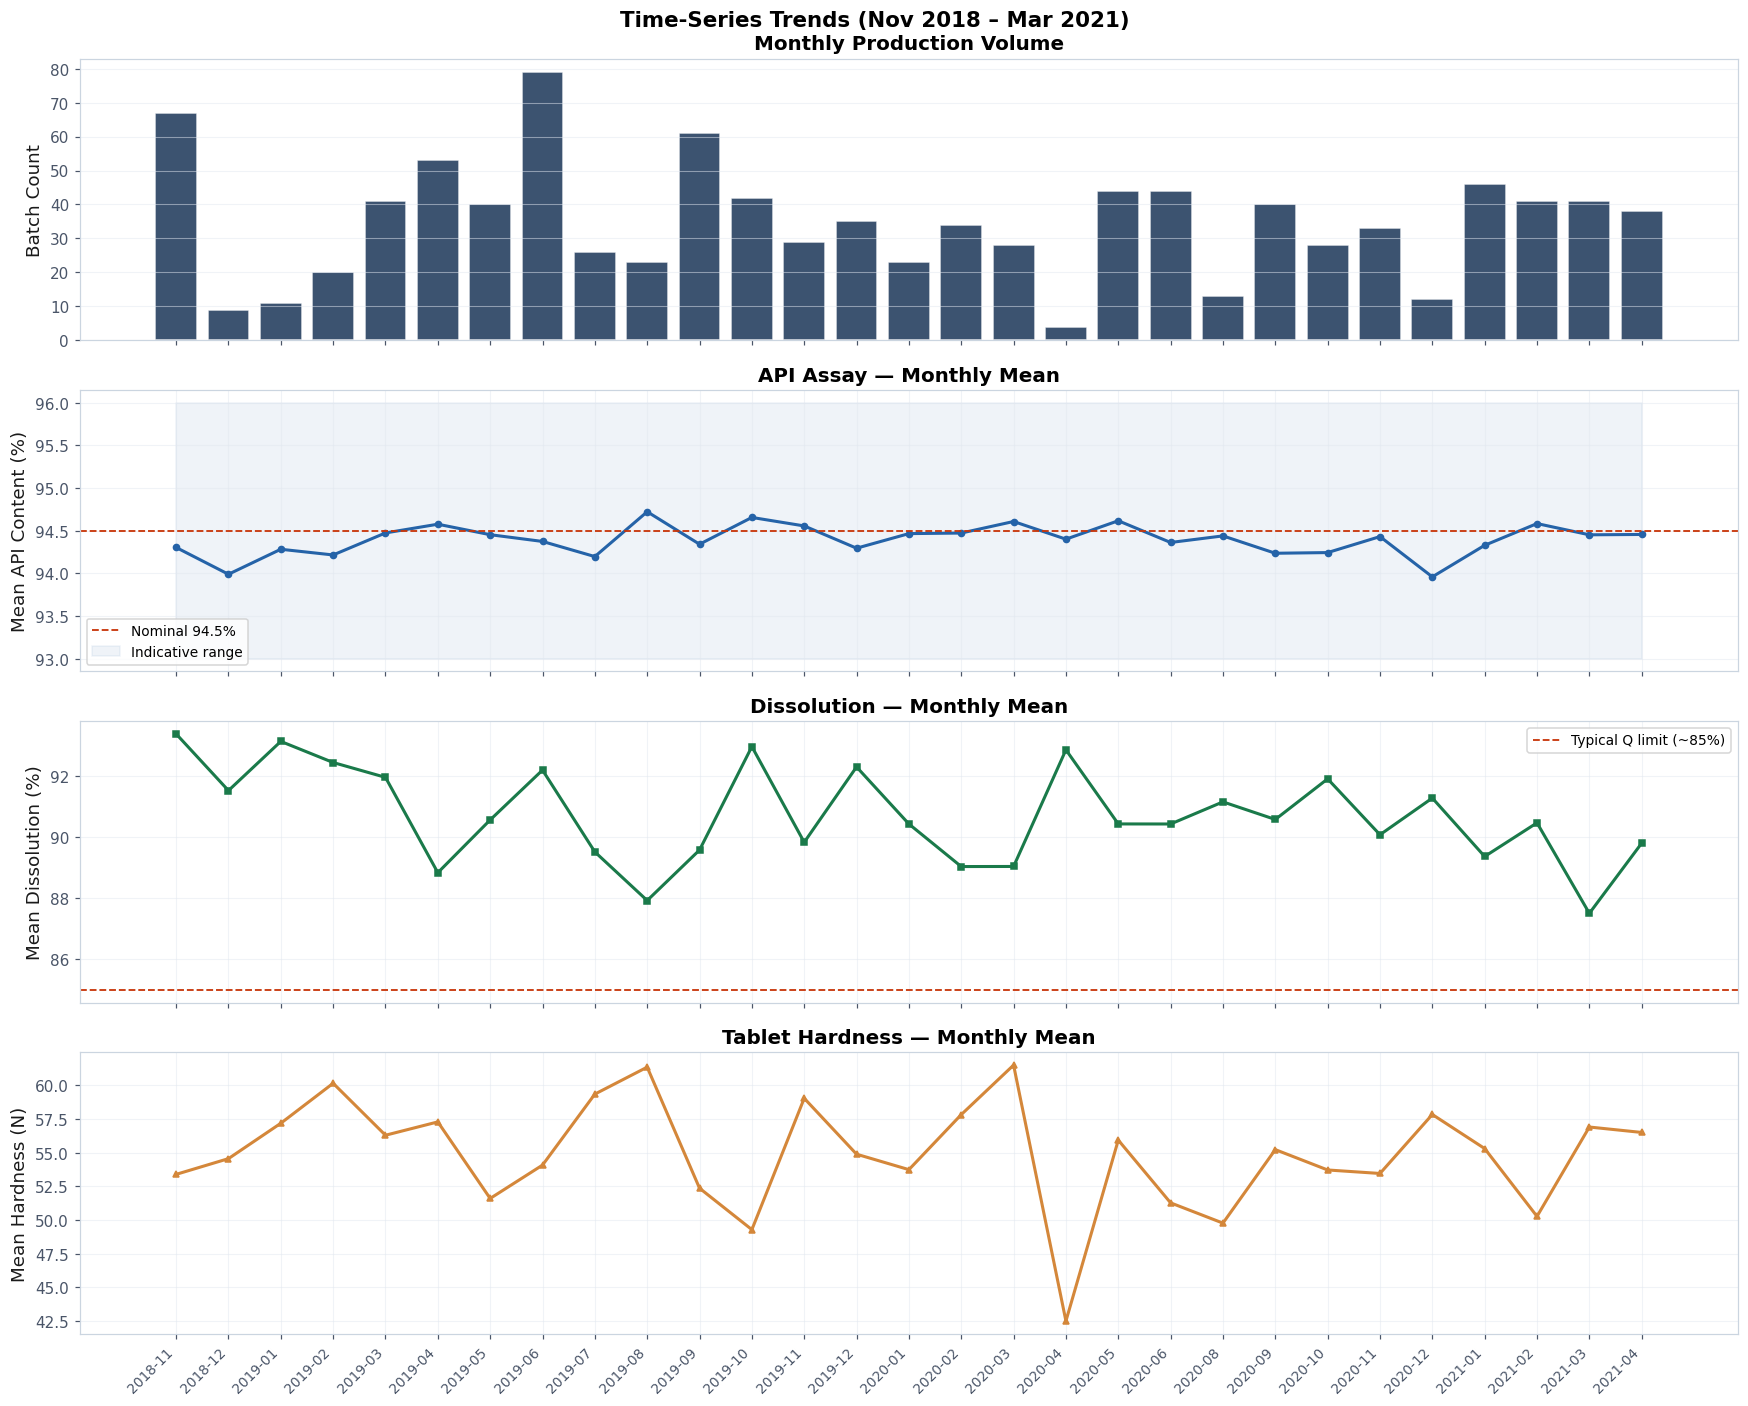

In [7]:
# Monthly batch count and key parameter trends over time
monthly = lab.groupby("period_str").agg(
    batch_count=("batch","count"),
    api_mean=("api_content","mean"),
    dissolution_mean=("dissolution_av","mean"),
    hardness_mean=("tbl_av_hardness","mean"),
).reset_index()

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
fig.suptitle("Time-Series Trends (Nov 2018 – Mar 2021)", fontsize=14, fontweight="bold")

periods = range(len(monthly))

# Batch volume
axes[0].bar(periods, monthly["batch_count"], color=NAVY, edgecolor="white", alpha=0.85)
axes[0].set_ylabel("Batch Count")
axes[0].set_title("Monthly Production Volume")
axes[0].grid(axis="y", alpha=0.5)

# API content
axes[1].plot(periods, monthly["api_mean"], color=BLUE, lw=2, marker="o", markersize=4)
axes[1].axhline(94.5, color=RED, ls="--", lw=1.2, label="Nominal 94.5%")
axes[1].fill_between(periods, 93.0, 96.0, alpha=0.07, color=BLUE, label="Indicative range")
axes[1].set_ylabel("Mean API Content (%)")
axes[1].set_title("API Assay — Monthly Mean")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.5)

# Dissolution
axes[2].plot(periods, monthly["dissolution_mean"], color=GREEN, lw=2, marker="s", markersize=4)
axes[2].axhline(85, color=RED, ls="--", lw=1.2, label="Typical Q limit (~85%)")
axes[2].set_ylabel("Mean Dissolution (%)")
axes[2].set_title("Dissolution — Monthly Mean")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.5)

# Hardness
axes[3].plot(periods, monthly["hardness_mean"], color=AMBER, lw=2, marker="^", markersize=4)
axes[3].set_ylabel("Mean Hardness (N)")
axes[3].set_title("Tablet Hardness — Monthly Mean")
axes[3].grid(alpha=0.5)

axes[3].set_xticks(periods)
axes[3].set_xticklabels(monthly["period_str"], rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("fig03_timeseries.png", bbox_inches="tight", dpi=130)
plt.show()


## 4. Key Quality Parameter Distributions

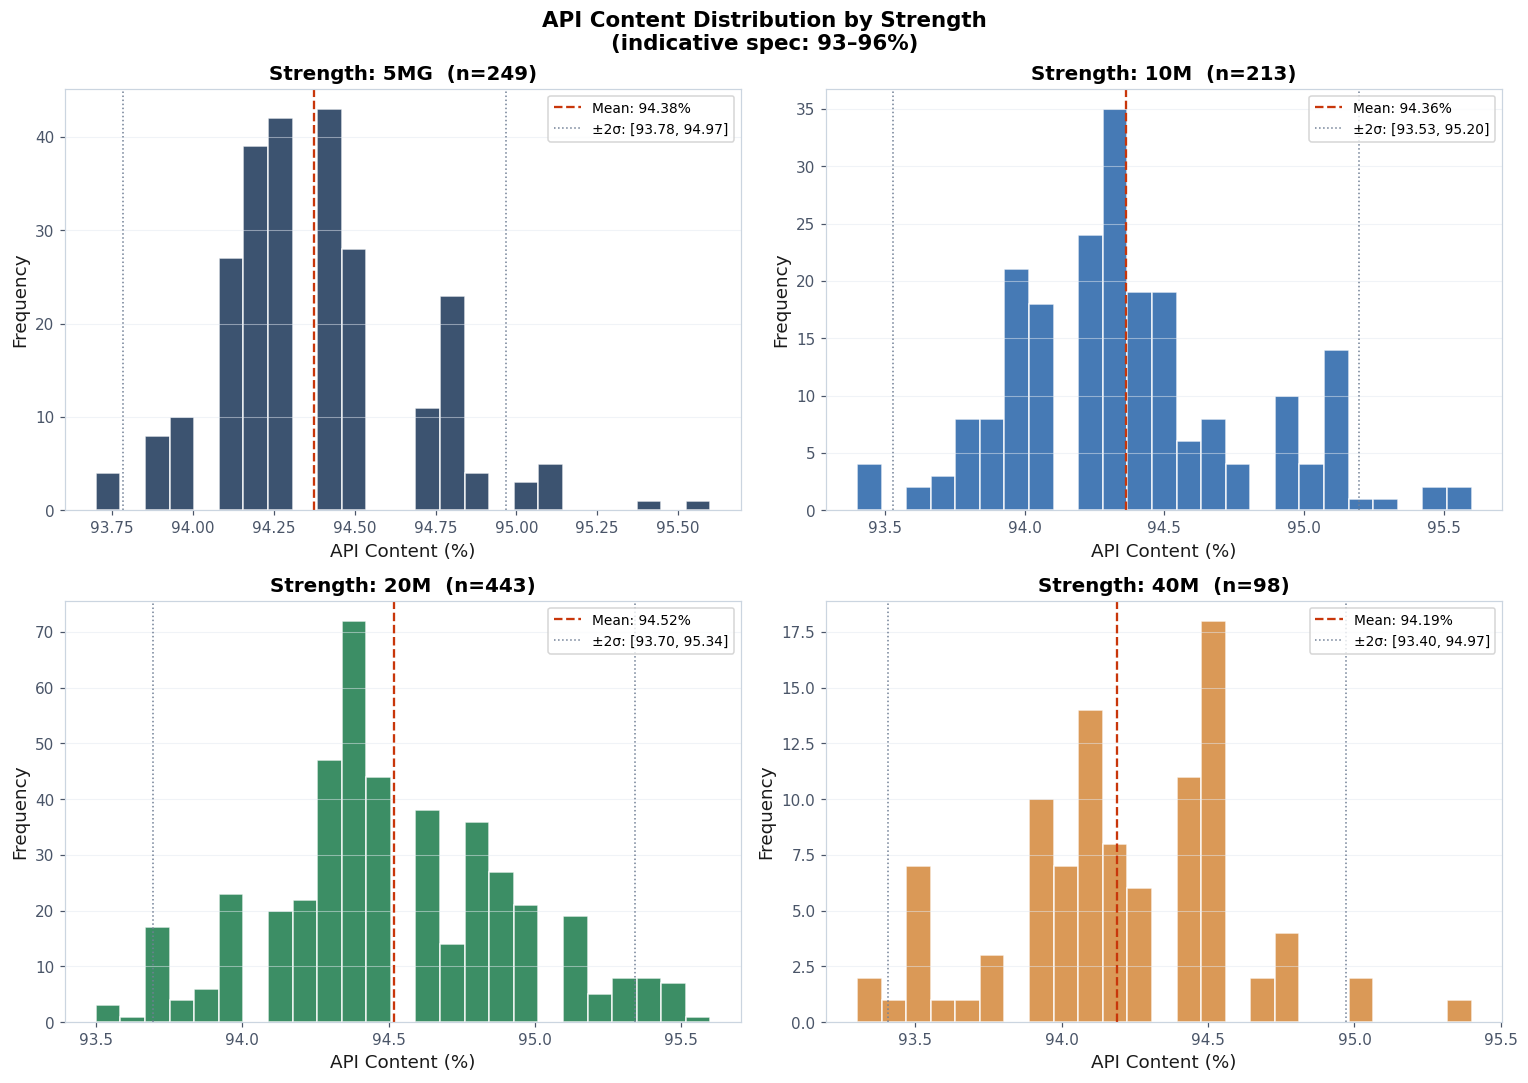

In [8]:
# ── 4a. API Content distribution by strength ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("API Content Distribution by Strength\n(indicative spec: 93–96%)", fontsize=14, fontweight="bold")

strength_colors = {"5MG": NAVY, "10M": BLUE, "20M": GREEN, "40M": AMBER}
for ax, strength in zip(axes.flatten(), lab["strength"].unique()):
    sub = lab[lab["strength"] == strength]["api_content"].dropna()
    color = strength_colors.get(strength, GREY)
    ax.hist(sub, bins=25, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(sub.mean(), color=RED, ls="--", lw=1.5, label=f"Mean: {sub.mean():.2f}%")
    ax.axvline(sub.mean() - 2*sub.std(), color=GREY, ls=":", lw=1, label=f"±2σ: [{sub.mean()-2*sub.std():.2f}, {sub.mean()+2*sub.std():.2f}]")
    ax.axvline(sub.mean() + 2*sub.std(), color=GREY, ls=":", lw=1)
    ax.set_title(f"Strength: {strength}  (n={len(sub)})")
    ax.set_xlabel("API Content (%)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.5)

plt.tight_layout()
plt.savefig("fig04a_api_by_strength.png", bbox_inches="tight", dpi=130)
plt.show()


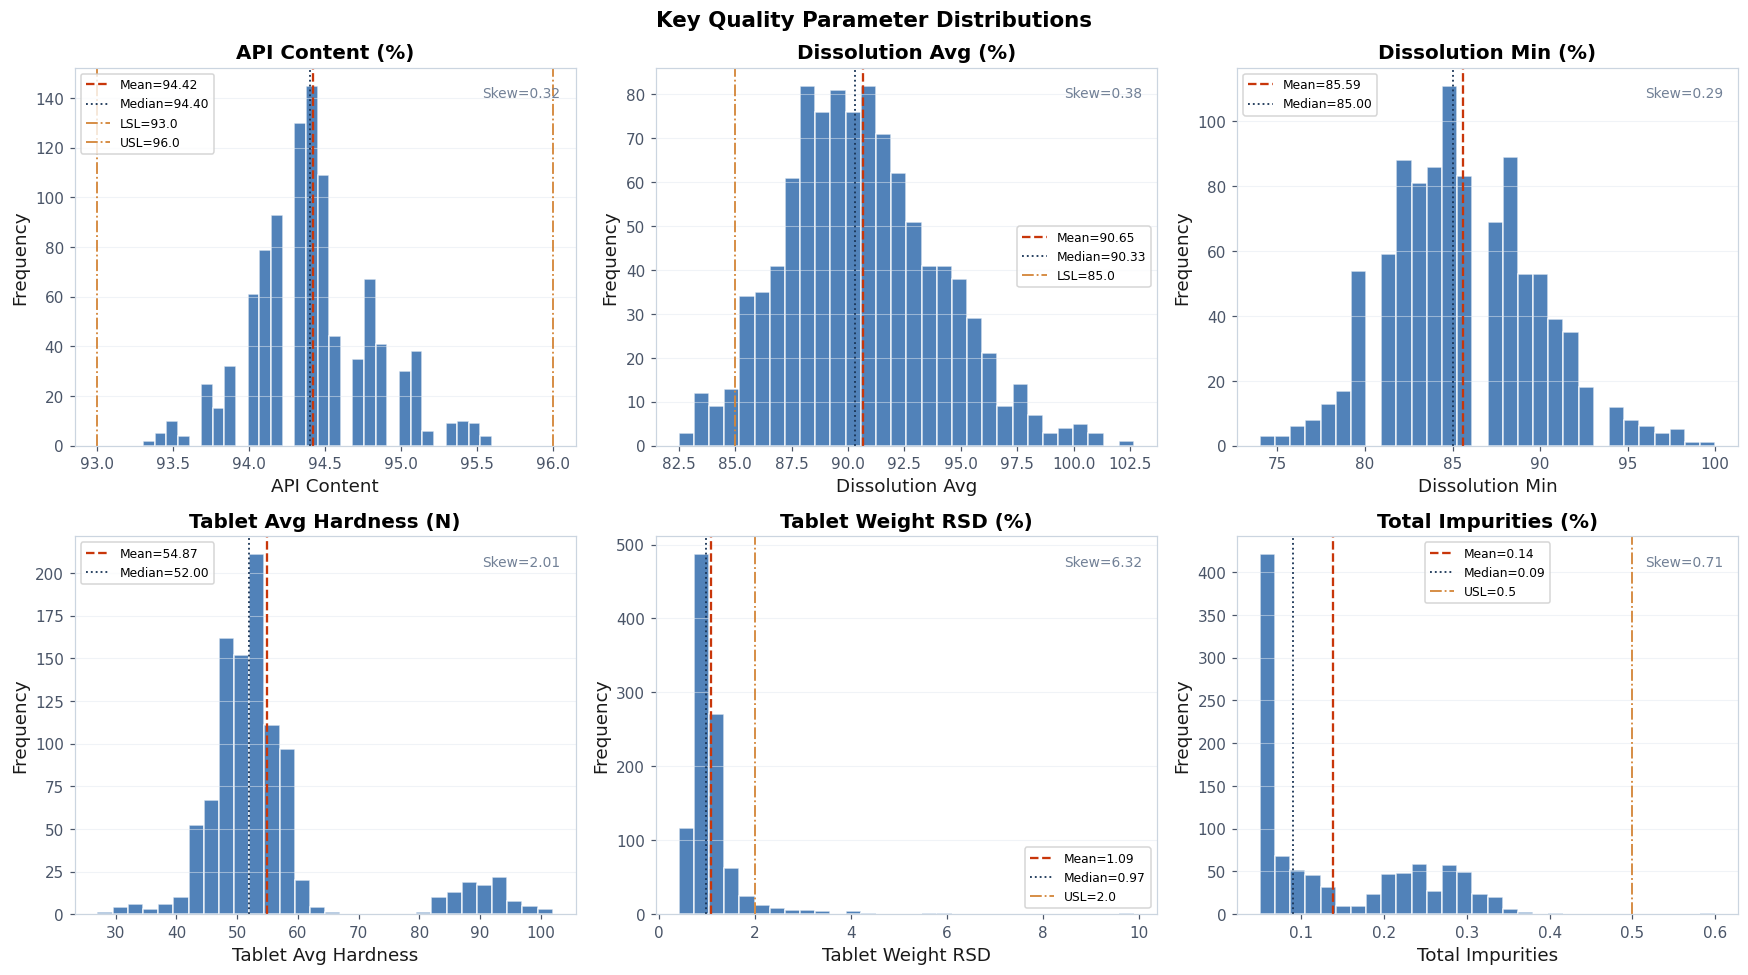

In [9]:
# ── 4b. Six key quality parameters side-by-side ──────────────────────────────
params = {
    "api_content":       ("API Content (%)",             93.0, 96.0),
    "dissolution_av":    ("Dissolution Avg (%)",          85.0, None),
    "dissolution_min":   ("Dissolution Min (%)",          None, None),
    "tbl_av_hardness":   ("Tablet Avg Hardness (N)",      None, None),
    "tbl_rsd_weight":    ("Tablet Weight RSD (%)",        None, 2.0),
    "impurities_total":  ("Total Impurities (%)",         None, 0.5),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Key Quality Parameter Distributions", fontsize=14, fontweight="bold")

for ax, (col, (label, lo_lim, hi_lim)) in zip(axes.flatten(), params.items()):
    data = lab[col].dropna()
    ax.hist(data, bins=30, color=BLUE, edgecolor="white", alpha=0.8)
    ax.axvline(data.mean(), color=RED,  ls="--", lw=1.5, label=f"Mean={data.mean():.2f}")
    ax.axvline(data.median(), color=NAVY, ls=":",  lw=1.2, label=f"Median={data.median():.2f}")
    if lo_lim is not None:
        ax.axvline(lo_lim, color=AMBER, ls="-.",  lw=1.2, label=f"LSL={lo_lim}")
    if hi_lim is not None:
        ax.axvline(hi_lim, color=AMBER, ls="-.",  lw=1.2, label=f"USL={hi_lim}")
    ax.set_title(label)
    ax.set_xlabel(label.split("(")[0].strip())
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.5)

    # Annotate skewness
    sk = stats.skew(data)
    ax.text(0.97, 0.95, f"Skew={sk:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color=GREY)

plt.tight_layout()
plt.savefig("fig04b_quality_params.png", bbox_inches="tight", dpi=130)
plt.show()


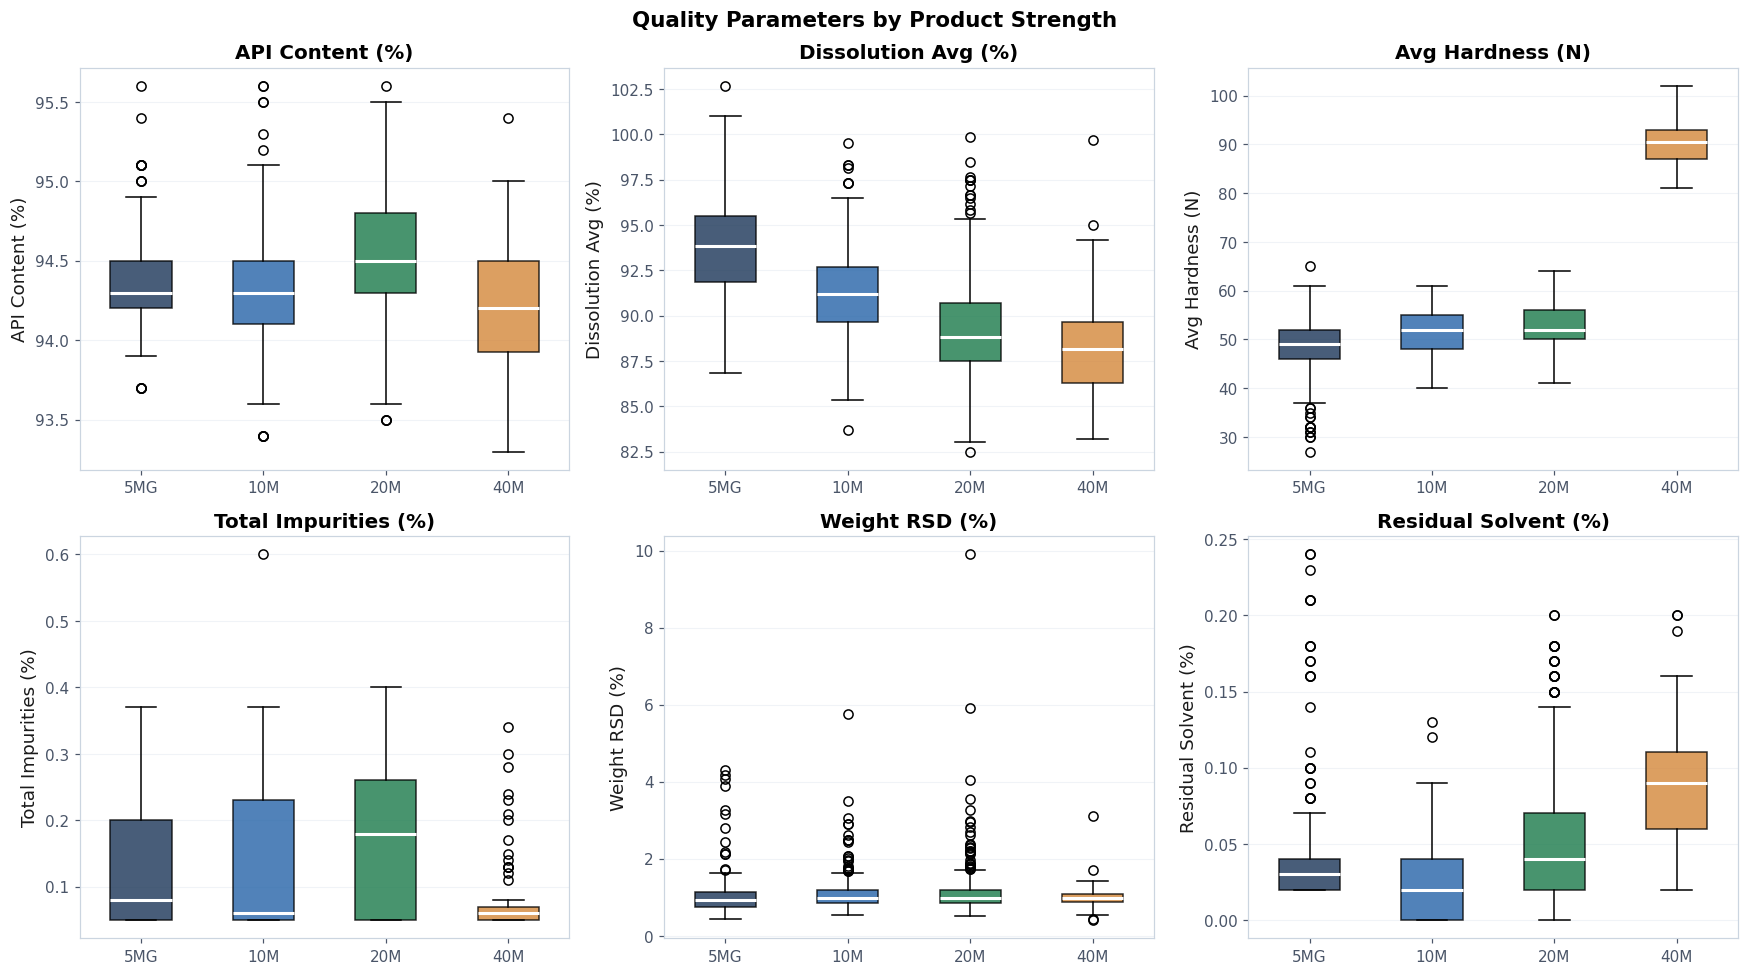

In [10]:
# ── 4c. Box plots stratified by strength ─────────────────────────────────────
key_boxplot = ["api_content", "dissolution_av", "tbl_av_hardness",
               "impurities_total", "tbl_rsd_weight", "resodual_solvent"]
labels_box  = ["API Content (%)", "Dissolution Avg (%)", "Avg Hardness (N)",
               "Total Impurities (%)", "Weight RSD (%)", "Residual Solvent (%)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Quality Parameters by Product Strength", fontsize=14, fontweight="bold")

palette = {"5MG": NAVY, "10M": BLUE, "20M": GREEN, "40M": AMBER}
for ax, col, lbl in zip(axes.flatten(), key_boxplot, labels_box):
    data_by_strength = [lab[lab["strength"]==s][col].dropna().values
                        for s in ["5MG","10M","20M","40M"]]
    bp = ax.boxplot(data_by_strength, patch_artist=True, widths=0.5,
                    medianprops=dict(color="white", lw=2))
    for patch, color in zip(bp["boxes"], [NAVY, BLUE, GREEN, AMBER]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_xticklabels(["5MG","10M","20M","40M"])
    ax.set_title(lbl)
    ax.set_ylabel(lbl)
    ax.grid(axis="y", alpha=0.5)

plt.tight_layout()
plt.savefig("fig04c_boxplot_strength.png", bbox_inches="tight", dpi=130)
plt.show()


## 5. Correlation Analysis

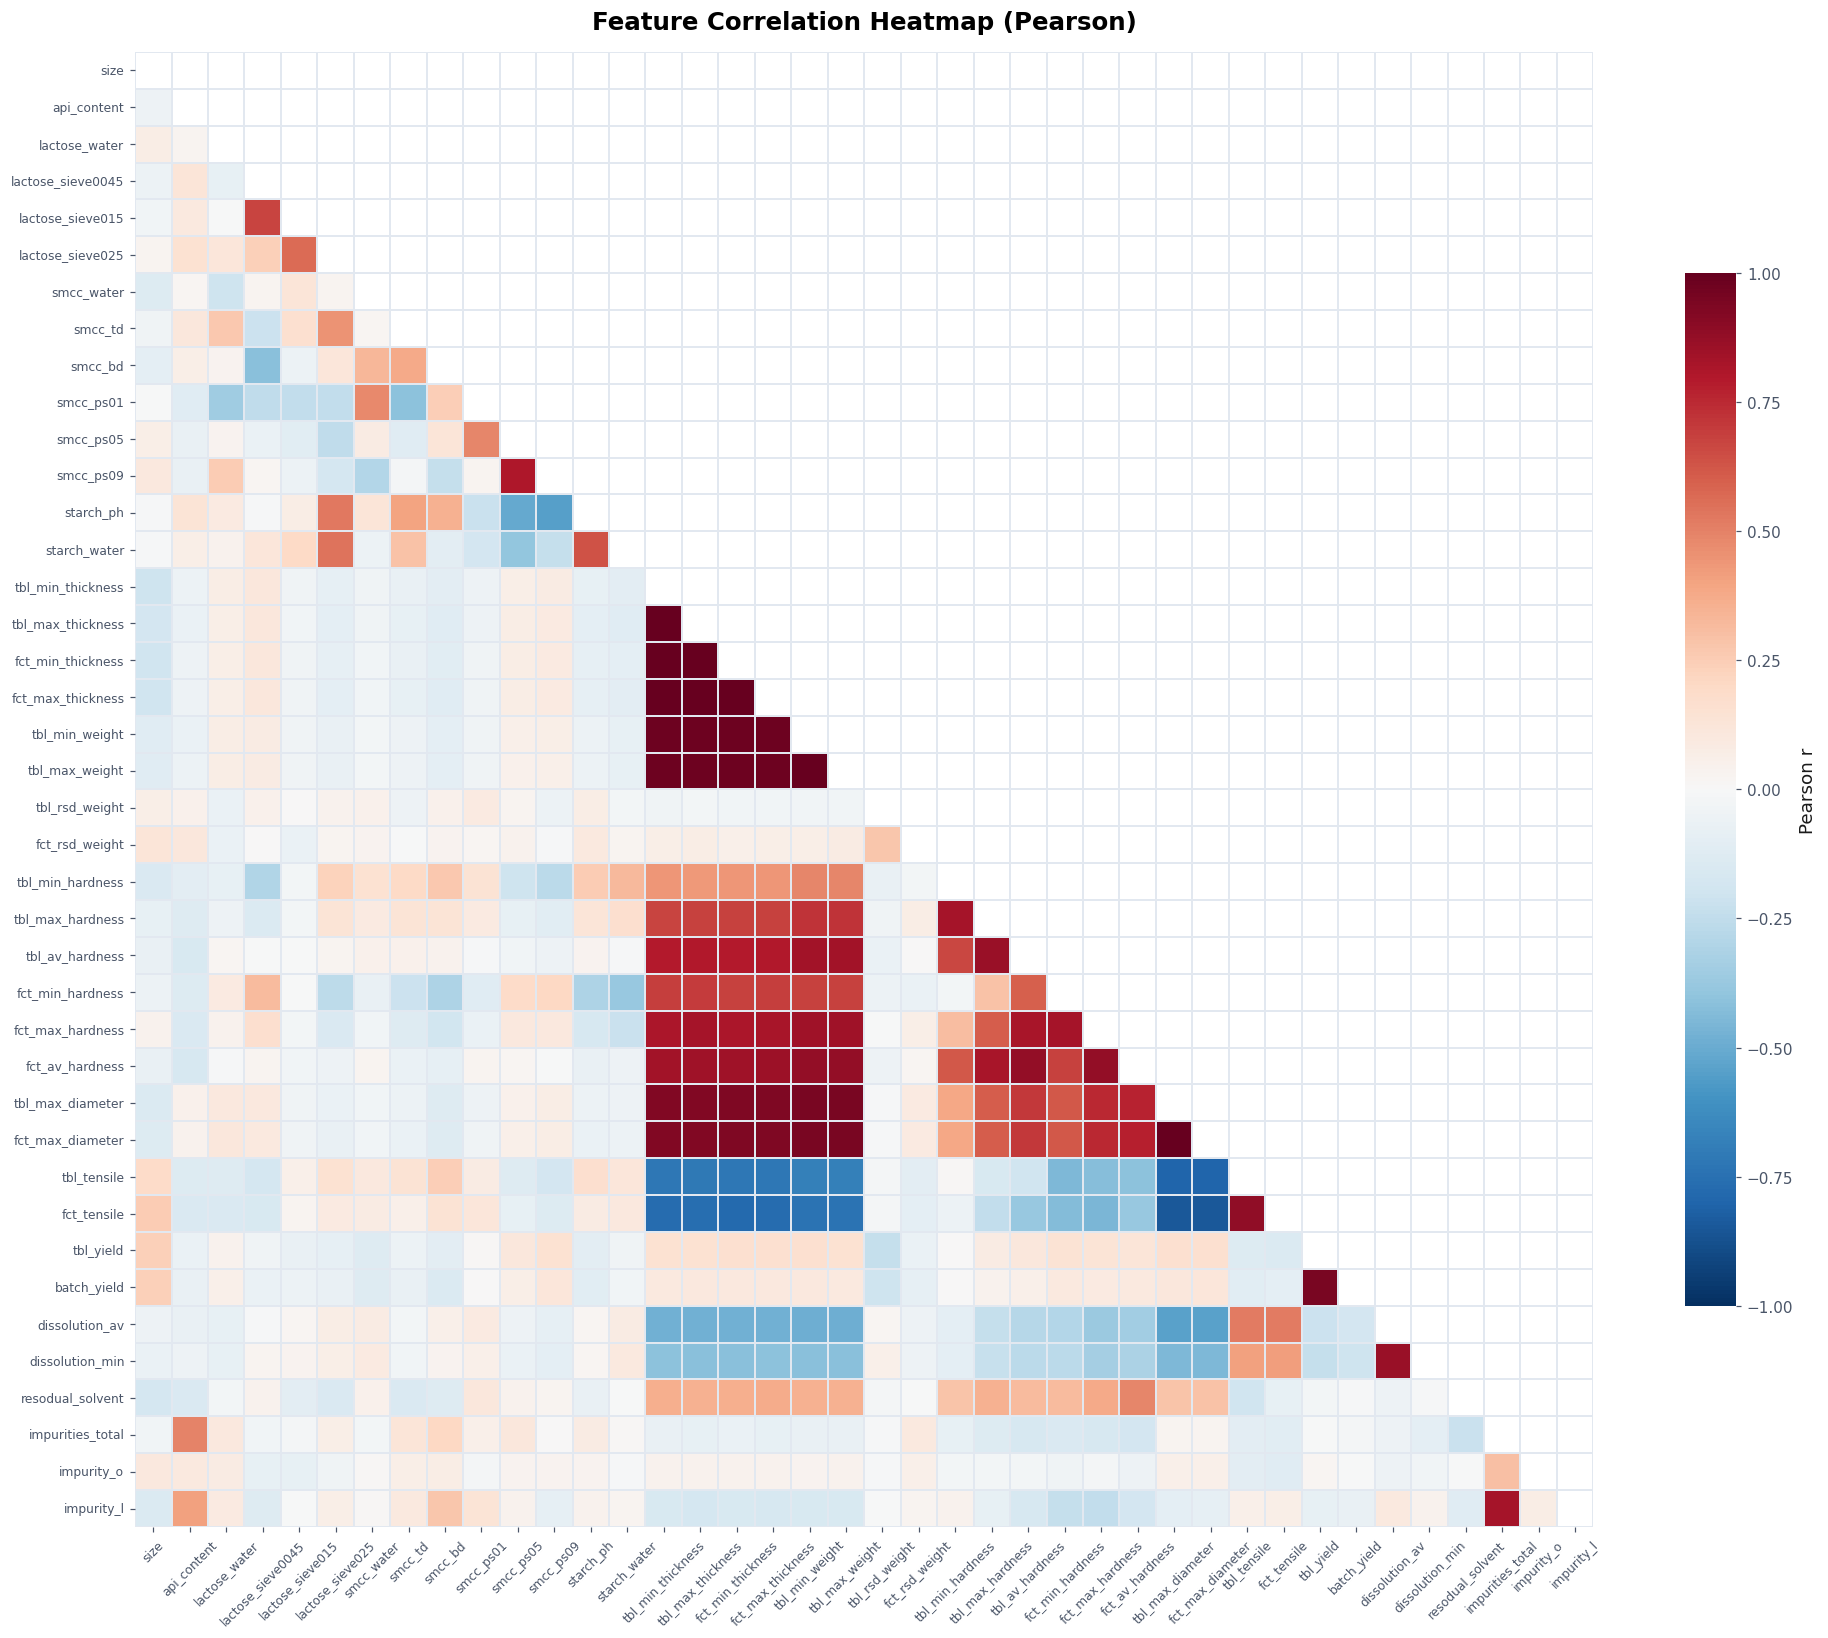

In [11]:
# ── Full correlation heatmap (numeric columns) ───────────────────────────────
num_cols = lab.select_dtypes(include=np.number).columns.tolist()
# Drop batch ID, code, and derived columns
drop_cols = ["batch","code","api_code","api_batch","smcc_batch",
             "lactose_batch","starch_batch","norm_factor"]
num_cols  = [c for c in num_cols if c not in drop_cols]

corr_mat = lab[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat, mask=mask, annot=False, cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor="#E2E8F0",
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    ax=ax,
)
ax.set_title("Feature Correlation Heatmap (Pearson)", fontsize=16, fontweight="bold", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("fig05a_corr_heatmap.png", bbox_inches="tight", dpi=130)
plt.show()


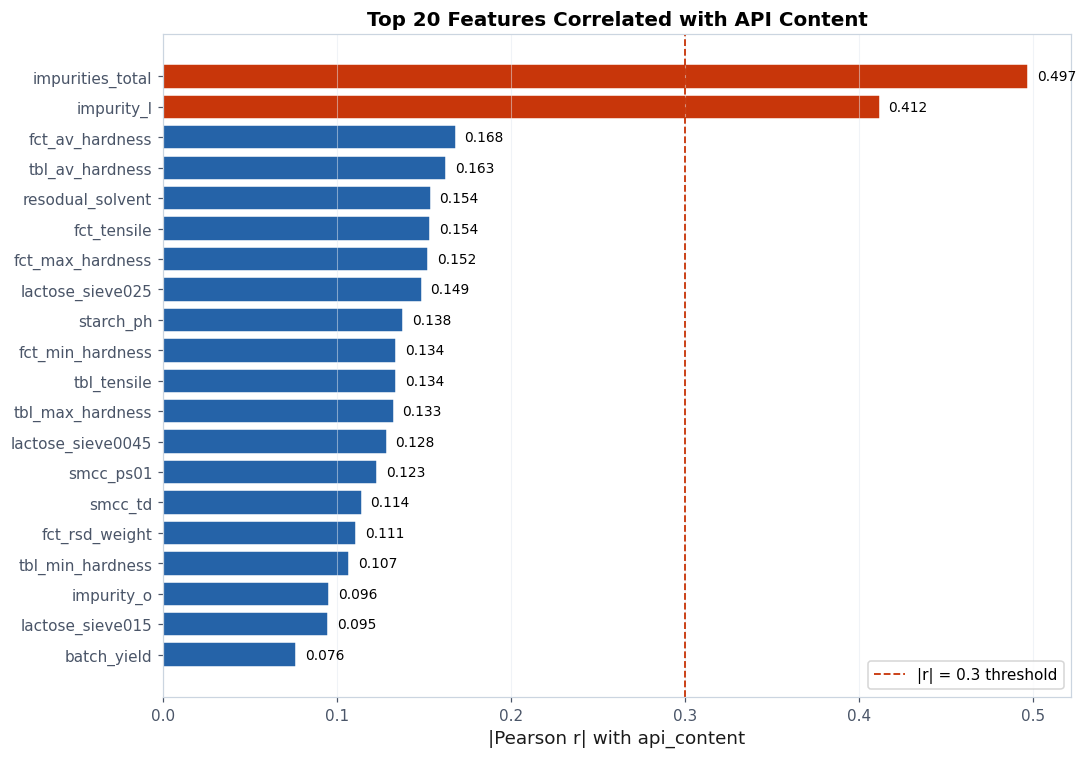

Features with |r| > 0.3 vs api_content:
impurities_total    0.497080
impurity_l          0.411947


In [12]:
# ── Top correlations with API content ────────────────────────────────────────
corr_api = corr_mat["api_content"].drop("api_content").abs().sort_values(ascending=False)
top20     = corr_api.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [RED if v > 0.3 else BLUE for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1], edgecolor="white")
ax.axvline(0.3, color=RED, ls="--", lw=1.2, label="|r| = 0.3 threshold")
ax.set_xlabel("|Pearson r| with api_content")
ax.set_title("Top 20 Features Correlated with API Content", fontweight="bold")
ax.legend()
ax.grid(axis="x", alpha=0.5)
for i, v in enumerate(top20.values[::-1]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig05b_corr_api.png", bbox_inches="tight", dpi=130)
plt.show()

print("Features with |r| > 0.3 vs api_content:")
print(corr_api[corr_api > 0.3].to_string())


## 6. Principal Component Analysis (PCA)

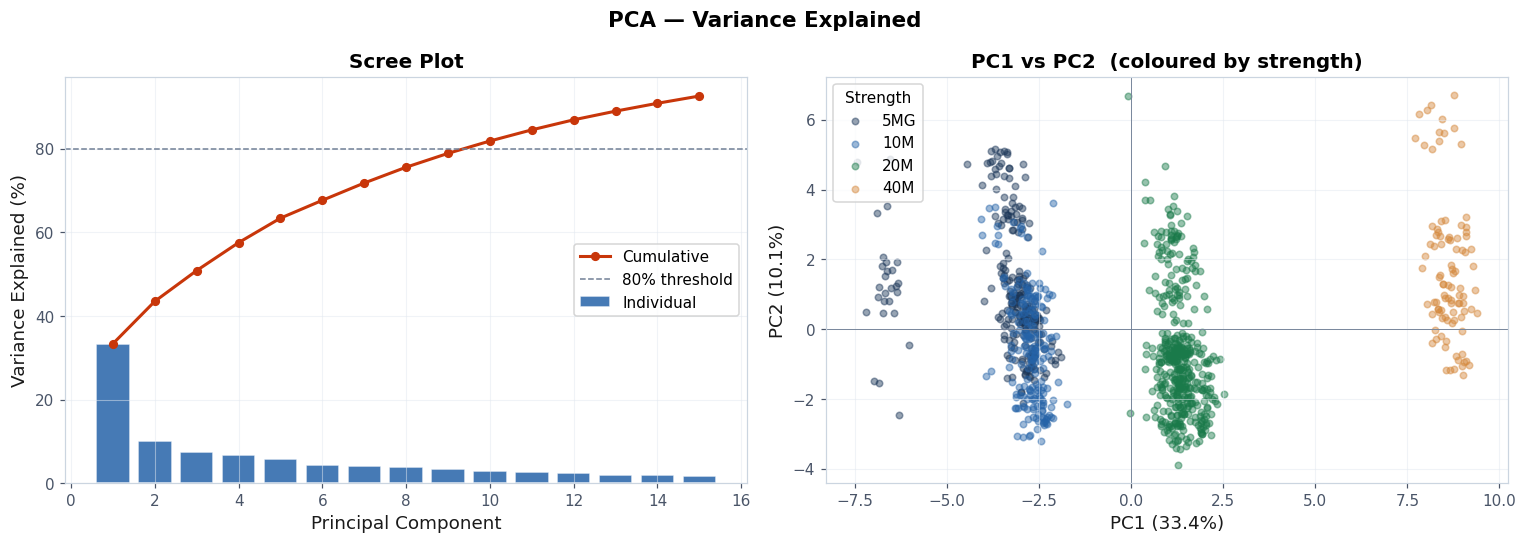

PC1 + PC2 explain 43.5% of variance
First 5 PCs explain 63.4% of variance


In [13]:
# ── Prepare: drop rows with any NaN in numeric feature cols ──────────────────
pca_cols = [c for c in num_cols if c != "api_content"]
df_pca   = lab[pca_cols + ["strength","api_content"]].dropna()

scaler = StandardScaler()
X_sc   = scaler.fit_transform(df_pca[pca_cols])

pca    = PCA(n_components=min(15, X_sc.shape[1]))
Z      = pca.fit_transform(X_sc)

# ── Variance explained ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA — Variance Explained", fontsize=14, fontweight="bold")

expl  = pca.explained_variance_ratio_ * 100
cumul = np.cumsum(expl)
n_pcs = len(expl)

axes[0].bar(range(1, n_pcs+1), expl, color=BLUE, edgecolor="white", alpha=0.85, label="Individual")
axes[0].plot(range(1, n_pcs+1), cumul, color=RED, marker="o", ms=5, lw=2, label="Cumulative")
axes[0].axhline(80, color=GREY, ls="--", lw=1, label="80% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_title("Scree Plot")
axes[0].legend()
axes[0].grid(alpha=0.5)

# ── Biplot PC1 vs PC2 ─────────────────────────────────────────────────────────
palette_s = {"5MG": NAVY, "10M": BLUE, "20M": GREEN, "40M": AMBER}
for strength, color in palette_s.items():
    mask_s = df_pca["strength"] == strength
    axes[1].scatter(Z[mask_s, 0], Z[mask_s, 1], c=color, alpha=0.45, s=18, label=strength)

axes[1].set_xlabel(f"PC1 ({expl[0]:.1f}%)")
axes[1].set_ylabel(f"PC2 ({expl[1]:.1f}%)")
axes[1].set_title("PC1 vs PC2  (coloured by strength)")
axes[1].legend(title="Strength")
axes[1].grid(alpha=0.5)
axes[1].axhline(0, color=GREY, lw=0.6); axes[1].axvline(0, color=GREY, lw=0.6)

plt.tight_layout()
plt.savefig("fig06a_pca.png", bbox_inches="tight", dpi=130)
plt.show()
print(f"PC1 + PC2 explain {cumul[1]:.1f}% of variance")
print(f"First 5 PCs explain {cumul[4]:.1f}% of variance")


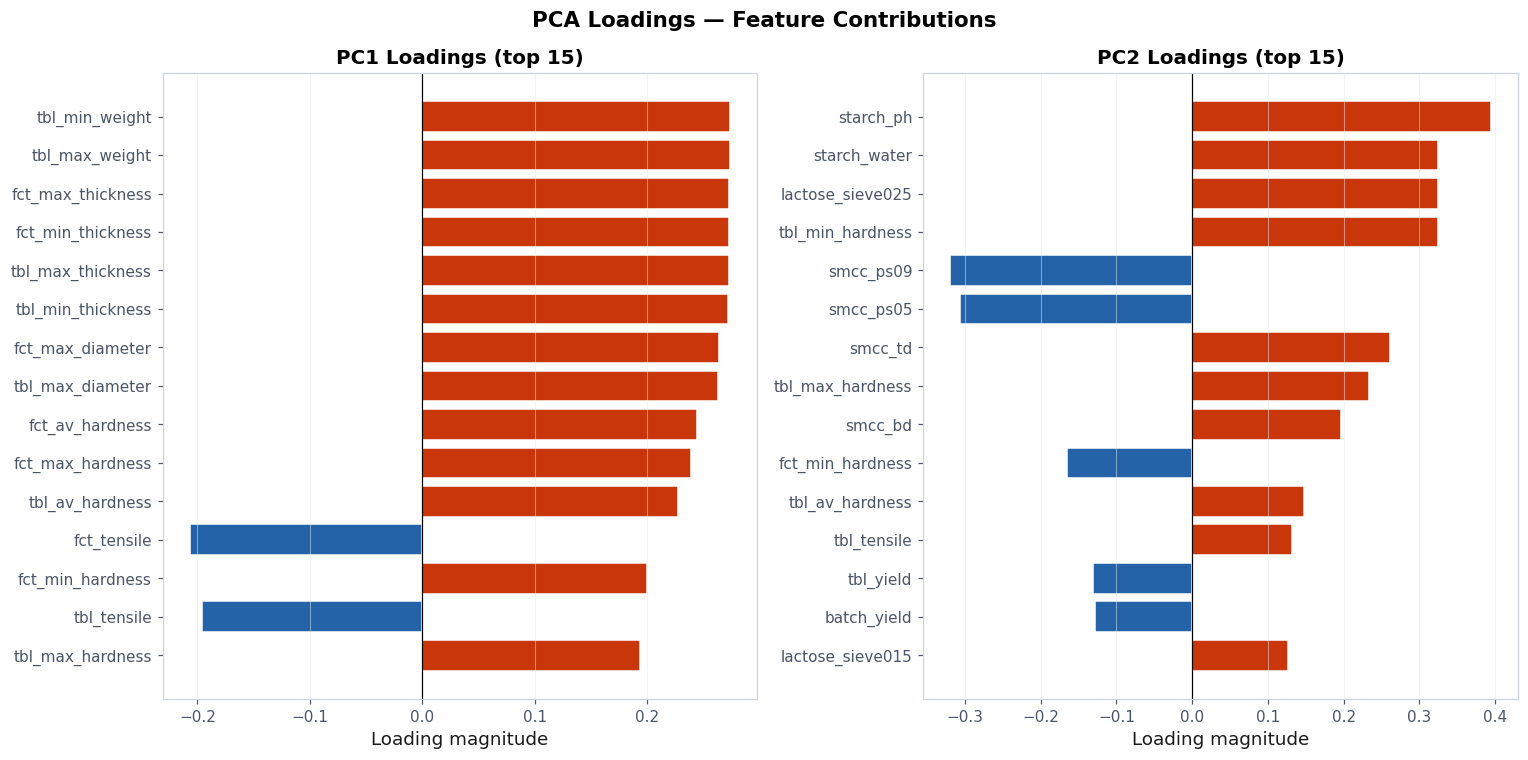

In [14]:
# ── PCA loadings: which features dominate PC1 and PC2? ──────────────────────
loadings = pd.DataFrame(pca.components_[:2].T,
                         index=pca_cols, columns=["PC1","PC2"])

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, pc in zip(axes, ["PC1","PC2"]):
    top = loadings[pc].abs().sort_values(ascending=False).head(15)
    vals = loadings[pc].loc[top.index]
    colors_load = [RED if v > 0 else BLUE for v in vals.values]
    ax.barh(top.index[::-1], vals.values[::-1], color=colors_load[::-1], edgecolor="white")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(f"{pc} Loadings (top 15)")
    ax.set_xlabel("Loading magnitude")
    ax.grid(axis="x", alpha=0.5)

plt.suptitle("PCA Loadings — Feature Contributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig06b_pca_loadings.png", bbox_inches="tight", dpi=130)
plt.show()


## 7. Anomaly Injection Preview

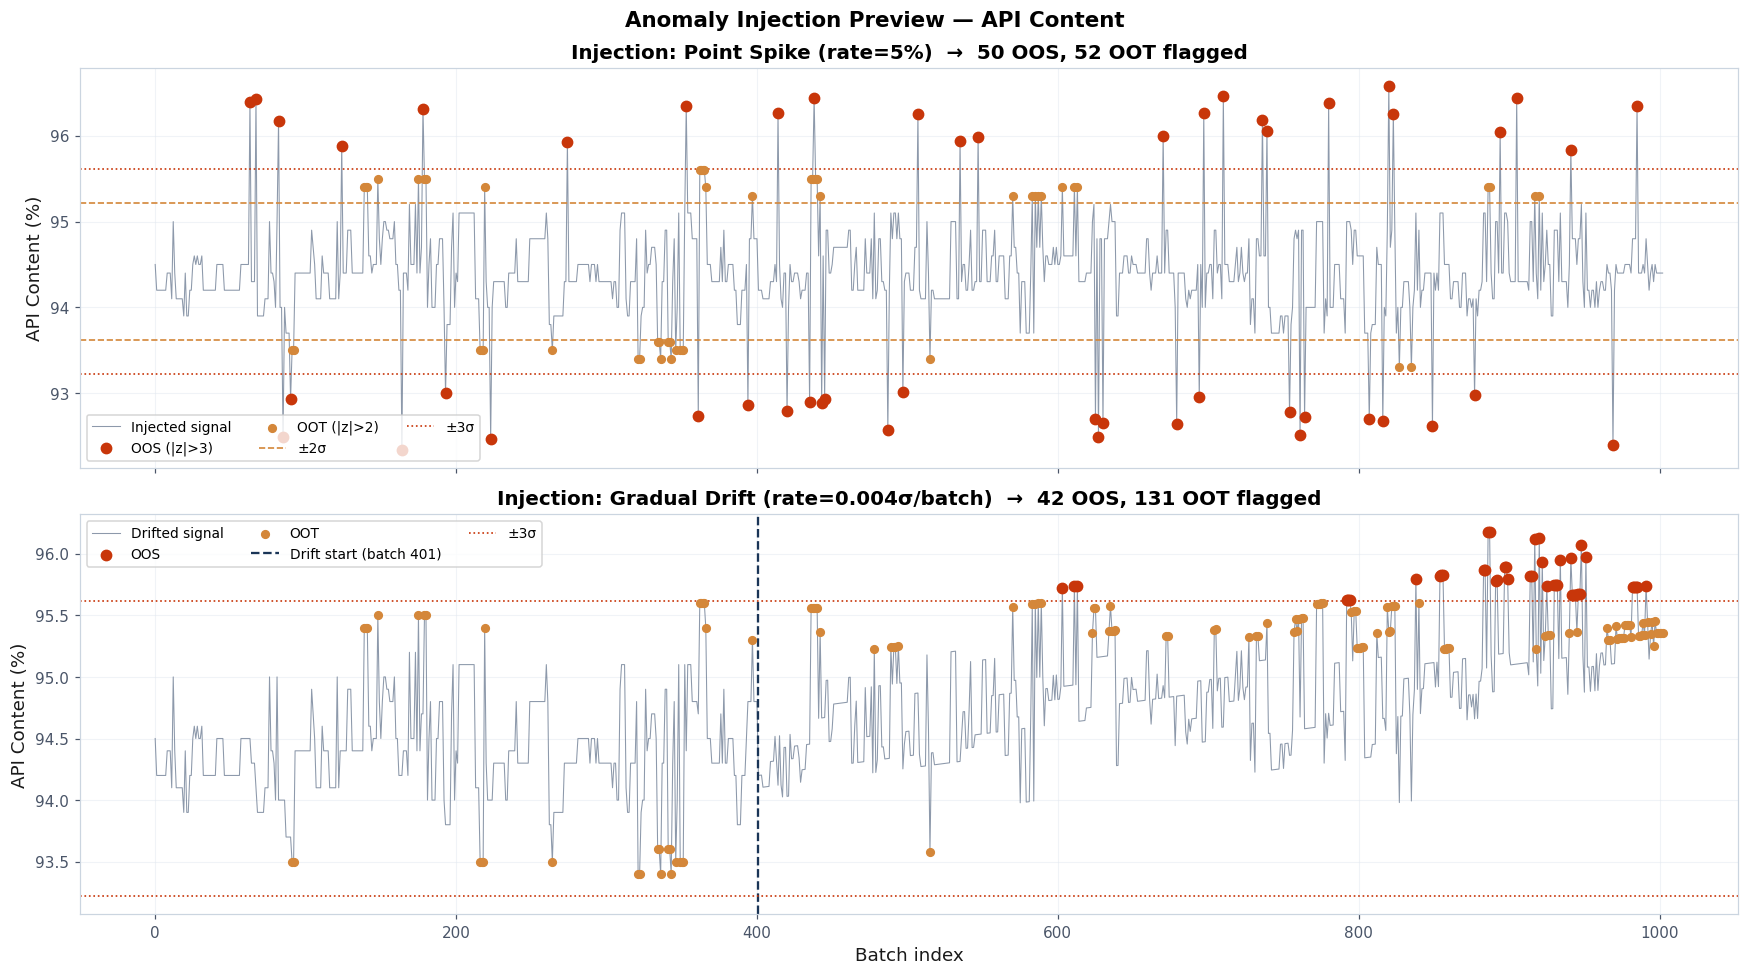

In [15]:
# ── Simulate one injection type on API content to verify visual signal ────────
api = lab["api_content"].dropna().reset_index(drop=True)
mu, sigma = api.mean(), api.std()

rng = np.random.default_rng(42)

# Point spike
spiked = api.copy()
spike_idx = rng.choice(len(api), size=int(len(api)*0.05), replace=False)
spike_k   = rng.uniform(3.5, 5.5, size=len(spike_idx))
spiked.iloc[spike_idx] = mu + rng.choice([-1,1], size=len(spike_idx)) * spike_k * sigma

# Gradual drift
drifted = api.copy()
start_d = int(len(api)*0.4)
for i in range(start_d, len(drifted)):
    drifted.iloc[i] += sigma * 0.004 * (i - start_d)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.suptitle("Anomaly Injection Preview — API Content", fontsize=14, fontweight="bold")

# Panel 1: point spikes
oos_mask = (spiked - mu).abs() > 3*sigma
oot_mask = ((spiked - mu).abs() > 2*sigma) & ~oos_mask

axes[0].plot(api.index, spiked, color=GREY, lw=0.7, alpha=0.8, label="Injected signal")
axes[0].scatter(api.index[oos_mask], spiked[oos_mask], color=RED,   s=45, zorder=5, label="OOS (|z|>3)")
axes[0].scatter(api.index[oot_mask], spiked[oot_mask], color=AMBER, s=25, zorder=4, label="OOT (|z|>2)")
axes[0].axhline(mu + 2*sigma, color=AMBER, ls="--", lw=1.1)
axes[0].axhline(mu - 2*sigma, color=AMBER, ls="--", lw=1.1, label="±2σ")
axes[0].axhline(mu + 3*sigma, color=RED,   ls=":",  lw=1.1)
axes[0].axhline(mu - 3*sigma, color=RED,   ls=":",  lw=1.1, label="±3σ")
axes[0].set_ylabel("API Content (%)")
axes[0].set_title(f"Injection: Point Spike (rate=5%)  →  {oos_mask.sum()} OOS, {oot_mask.sum()} OOT flagged")
axes[0].legend(fontsize=9, ncol=3)
axes[0].grid(alpha=0.5)

# Panel 2: gradual drift
oos_d = (drifted - mu).abs() > 3*sigma
oot_d = ((drifted - mu).abs() > 2*sigma) & ~oos_d

axes[1].plot(api.index, drifted, color=GREY, lw=0.7, alpha=0.8, label="Drifted signal")
axes[1].scatter(api.index[oos_d], drifted[oos_d], color=RED,   s=45, zorder=5, label="OOS")
axes[1].scatter(api.index[oot_d], drifted[oot_d], color=AMBER, s=25, zorder=4, label="OOT")
axes[1].axvline(start_d, color=NAVY, ls="--", lw=1.5, label=f"Drift start (batch {start_d})")
axes[1].axhline(mu + 3*sigma, color=RED,   ls=":", lw=1.1, label="±3σ")
axes[1].axhline(mu - 3*sigma, color=RED,   ls=":", lw=1.1)
axes[1].set_xlabel("Batch index")
axes[1].set_ylabel("API Content (%)")
axes[1].set_title(f"Injection: Gradual Drift (rate=0.004σ/batch)  →  {oos_d.sum()} OOS, {oot_d.sum()} OOT flagged")
axes[1].legend(fontsize=9, ncol=3)
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.savefig("fig07_injection_preview.png", bbox_inches="tight", dpi=130)
plt.show()


## 8. Summary & Implications for RCA Modelling

In [ ]:
# ── Descriptive summary table ─────────────────────────────────────────────────
summary_cols = {
    "api_content":       "API Content (%)",
    "dissolution_av":    "Dissolution Avg (%)",
    "dissolution_min":   "Dissolution Min (%)",
    "tbl_av_hardness":   "Avg Hardness (N)",
    "tbl_rsd_weight":    "Weight RSD (%)",
    "impurities_total":  "Total Impurities (%)",
    "resodual_solvent":  "Residual Solvent (%)"
    # "api_water":         "API Water Content (%)",
}

rows = []
for col, label in summary_cols.items():
    d = lab[col].dropna()
    z3 = ((d - d.mean()).abs() > 3*d.std()).sum()
    z2 = (((d - d.mean()).abs() > 2*d.std()) & ((d - d.mean()).abs() <= 3*d.std())).sum()
    rows.append({
        "Parameter":    label,
        "n":            len(d),
        "Mean":         round(d.mean(), 3),
        "Std":          round(d.std(), 3),
        "CV (%)":       round(d.std()/d.mean()*100, 2),
        "Min":          round(d.min(), 3),
        "Max":          round(d.max(), 3),
        "z>2 (OOT)":    z2,
        "z>3 (OOS)":    z3,
    })

summary_df = pd.DataFrame(rows).set_index("Parameter")
print("Statistical summary of key quality parameters:")
# print(summary_df.to_string())
summary_df


In [ ]:
# ── Key takeaways ─────────────────────────────────────────────────────────────
print("""
┌────────────────────────────────────────────────────────────────────────────┐
│  EDA Key Findings — Žagar 2022 Laboratory Dataset                          │
├────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  Dataset                                                                    │
│  • 1,005 batches · 55 features · 4 strengths · Nov 2018 – Mar 2021         │
│  • Only 36 missing values across 5 columns (<0.7% of data)                 │
│                                                                              │
│  All batches in-specification                                               │
│  • API content: mean 94.42%, σ 0.40%  (spec: ~93–96%)                     │
│  • Dissolution avg: mean 90.65%, σ 3.37%  (Q limit ~85%)                   │
│  • No real OOS/OOT labels → anomaly injection required for ML              │
│                                                                              │
│  Feature correlations with API content                                      │
│  • impurities_total (|r|=0.50) and impurity_l (|r|=0.41) are strongest     │
│  • Hardness metrics show moderate correlation (|r|≈0.16)                   │
│  • Process and raw material features are largely independent                │
│                                                                              │
│  PCA structure                                                              │
│  • Strong product-code clustering visible in PC1–PC2 space                 │
│  • Hardness & tensile features dominate PC1                                │
│  • Raw material (API PSD, lactose sieve) features dominate PC2             │
│                                                                              │
│  Implications for anomaly injection                                         │
│  • Low σ on API content means injecting k=3.5–5σ spikes will              │
│    clearly separate OOS from normal variation                               │
│  • Gradual drift (rate 0.003–0.005σ/batch) produces realistic OOT          │
│  • Variance inflation (scale 3×) sufficient to trigger Levene test         │
│                                                                              │
└────────────────────────────────────────────────────────────────────────────┘
""")
